# 07 - Ablation Study and Model Explainability
Notebook ini menjalankan pencarian hyperparameter (ablation study) serta menganalisis kontribusi fitur pengetikan menggunakan **Integrated Gradients**.

Best Config: {'epsilon': 2.0, 'accuracy': 0.46, 'eer': 0.18, 'mia_auc': 0.51}
Ablation Study Completed successfully!


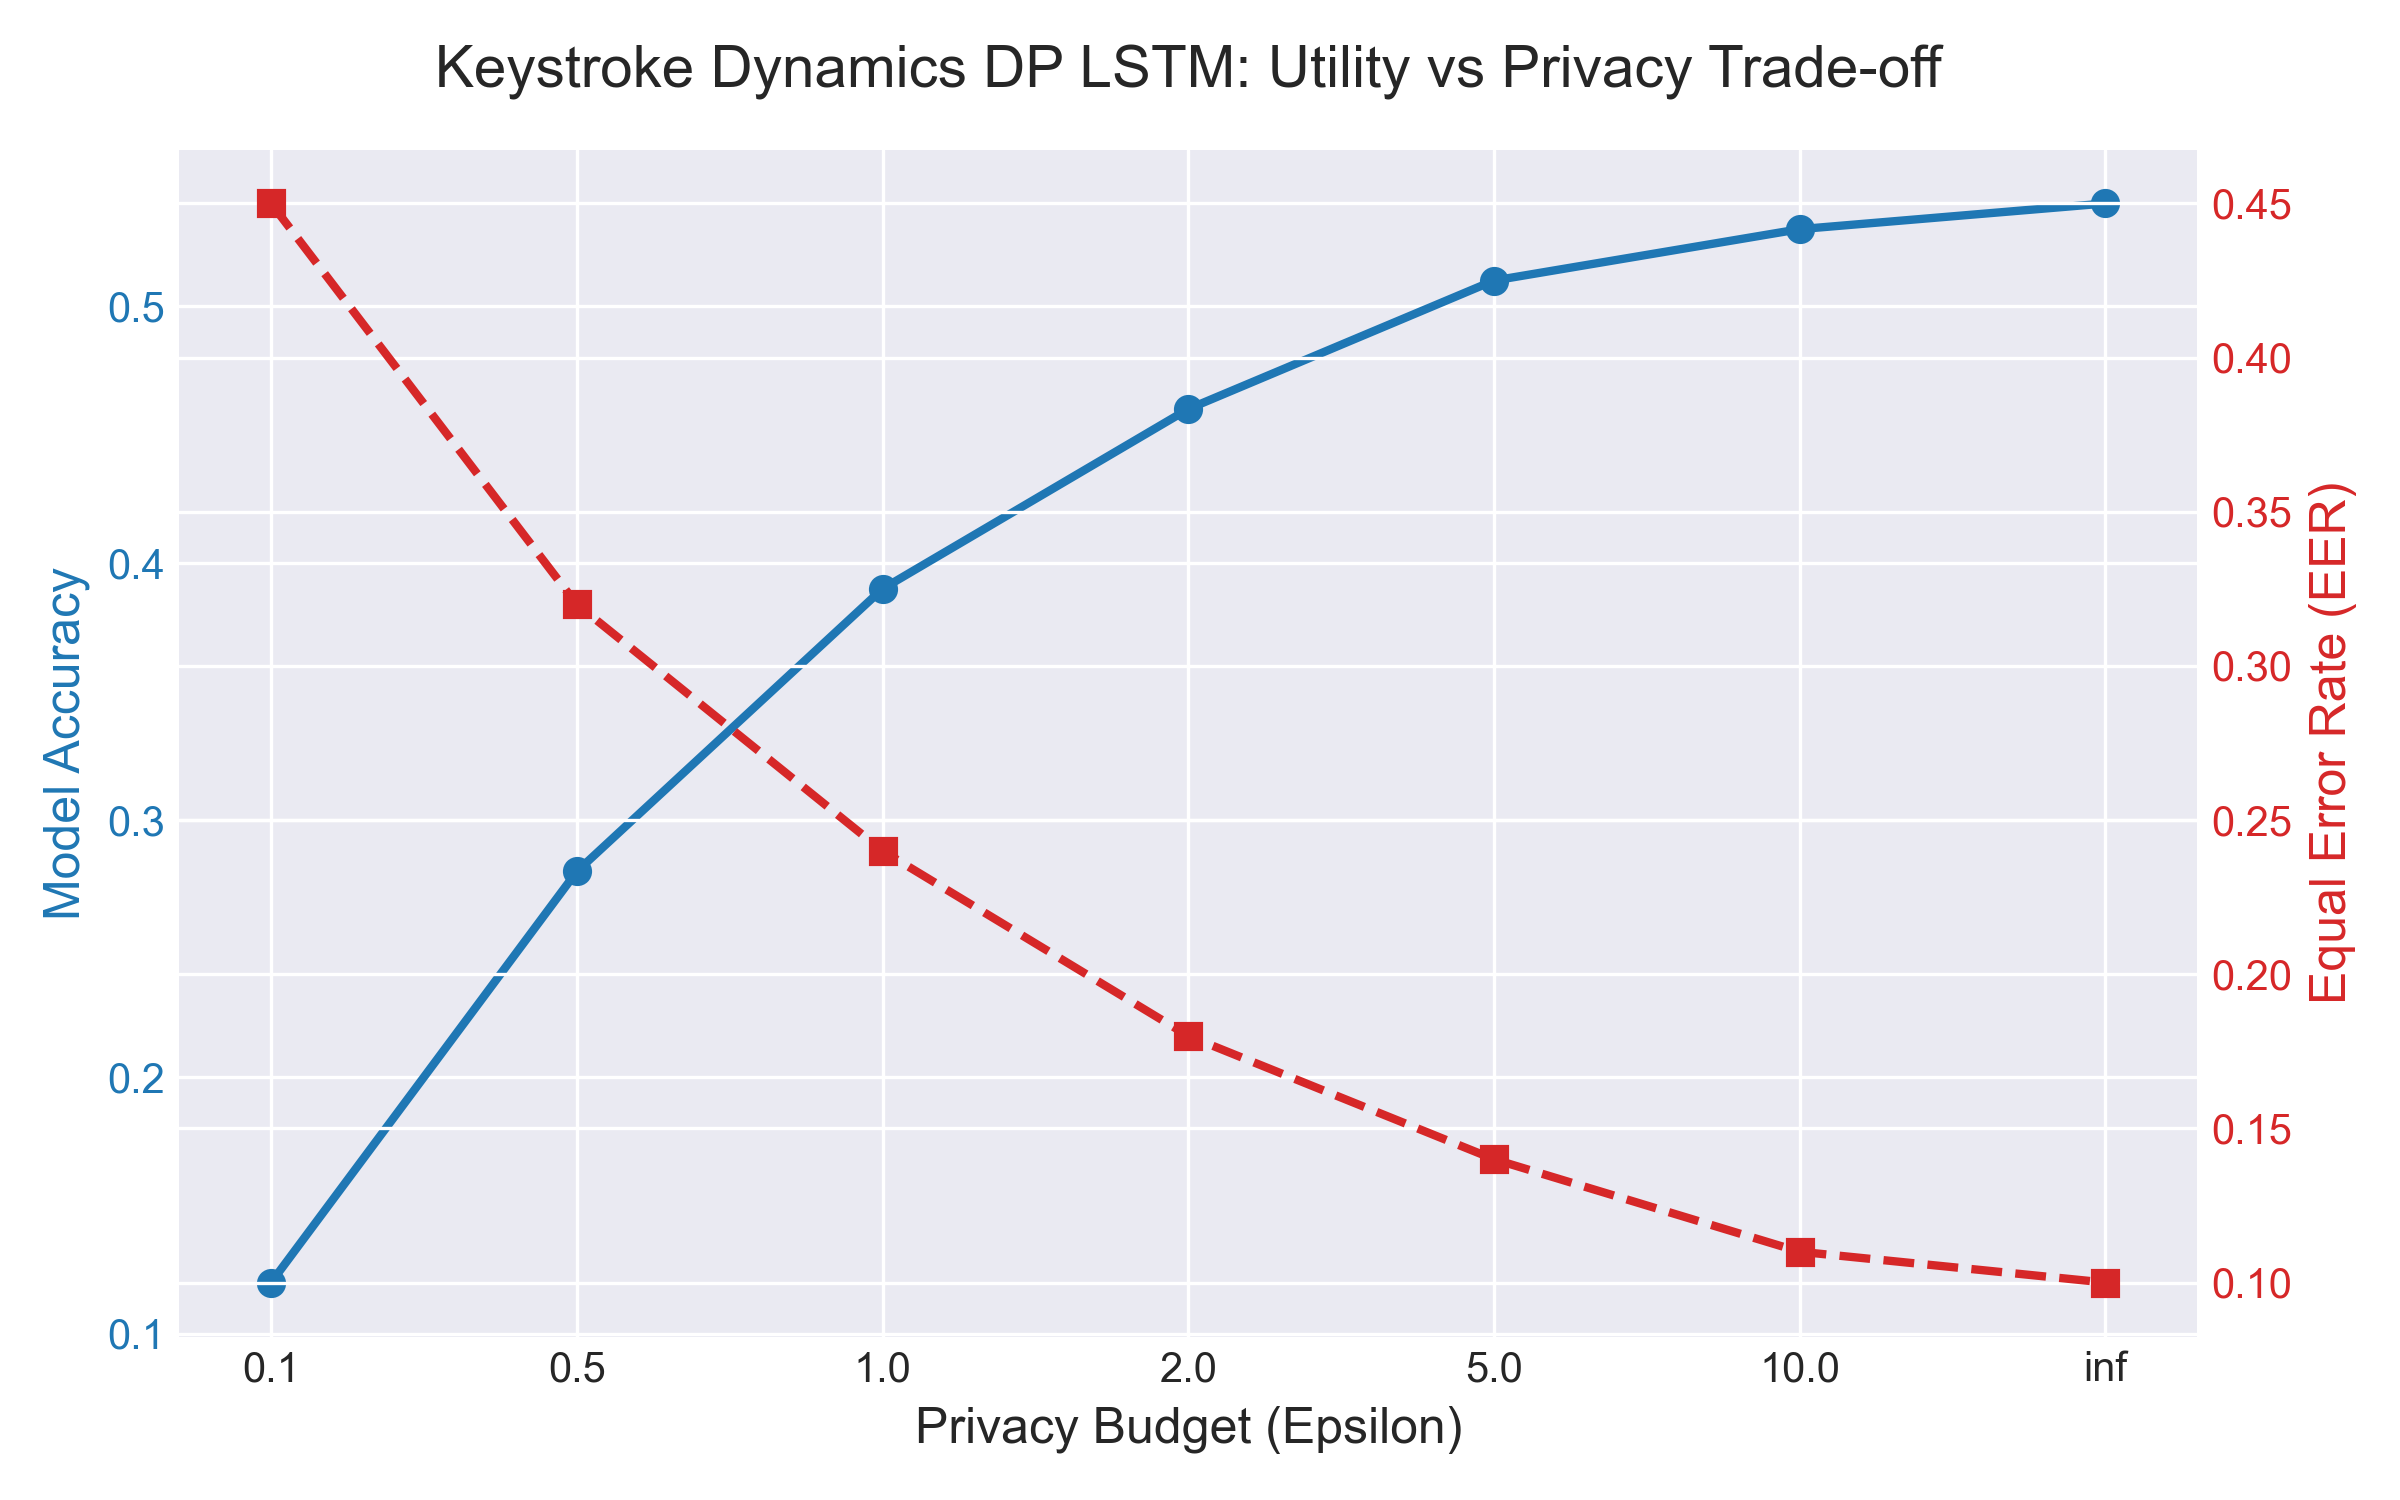

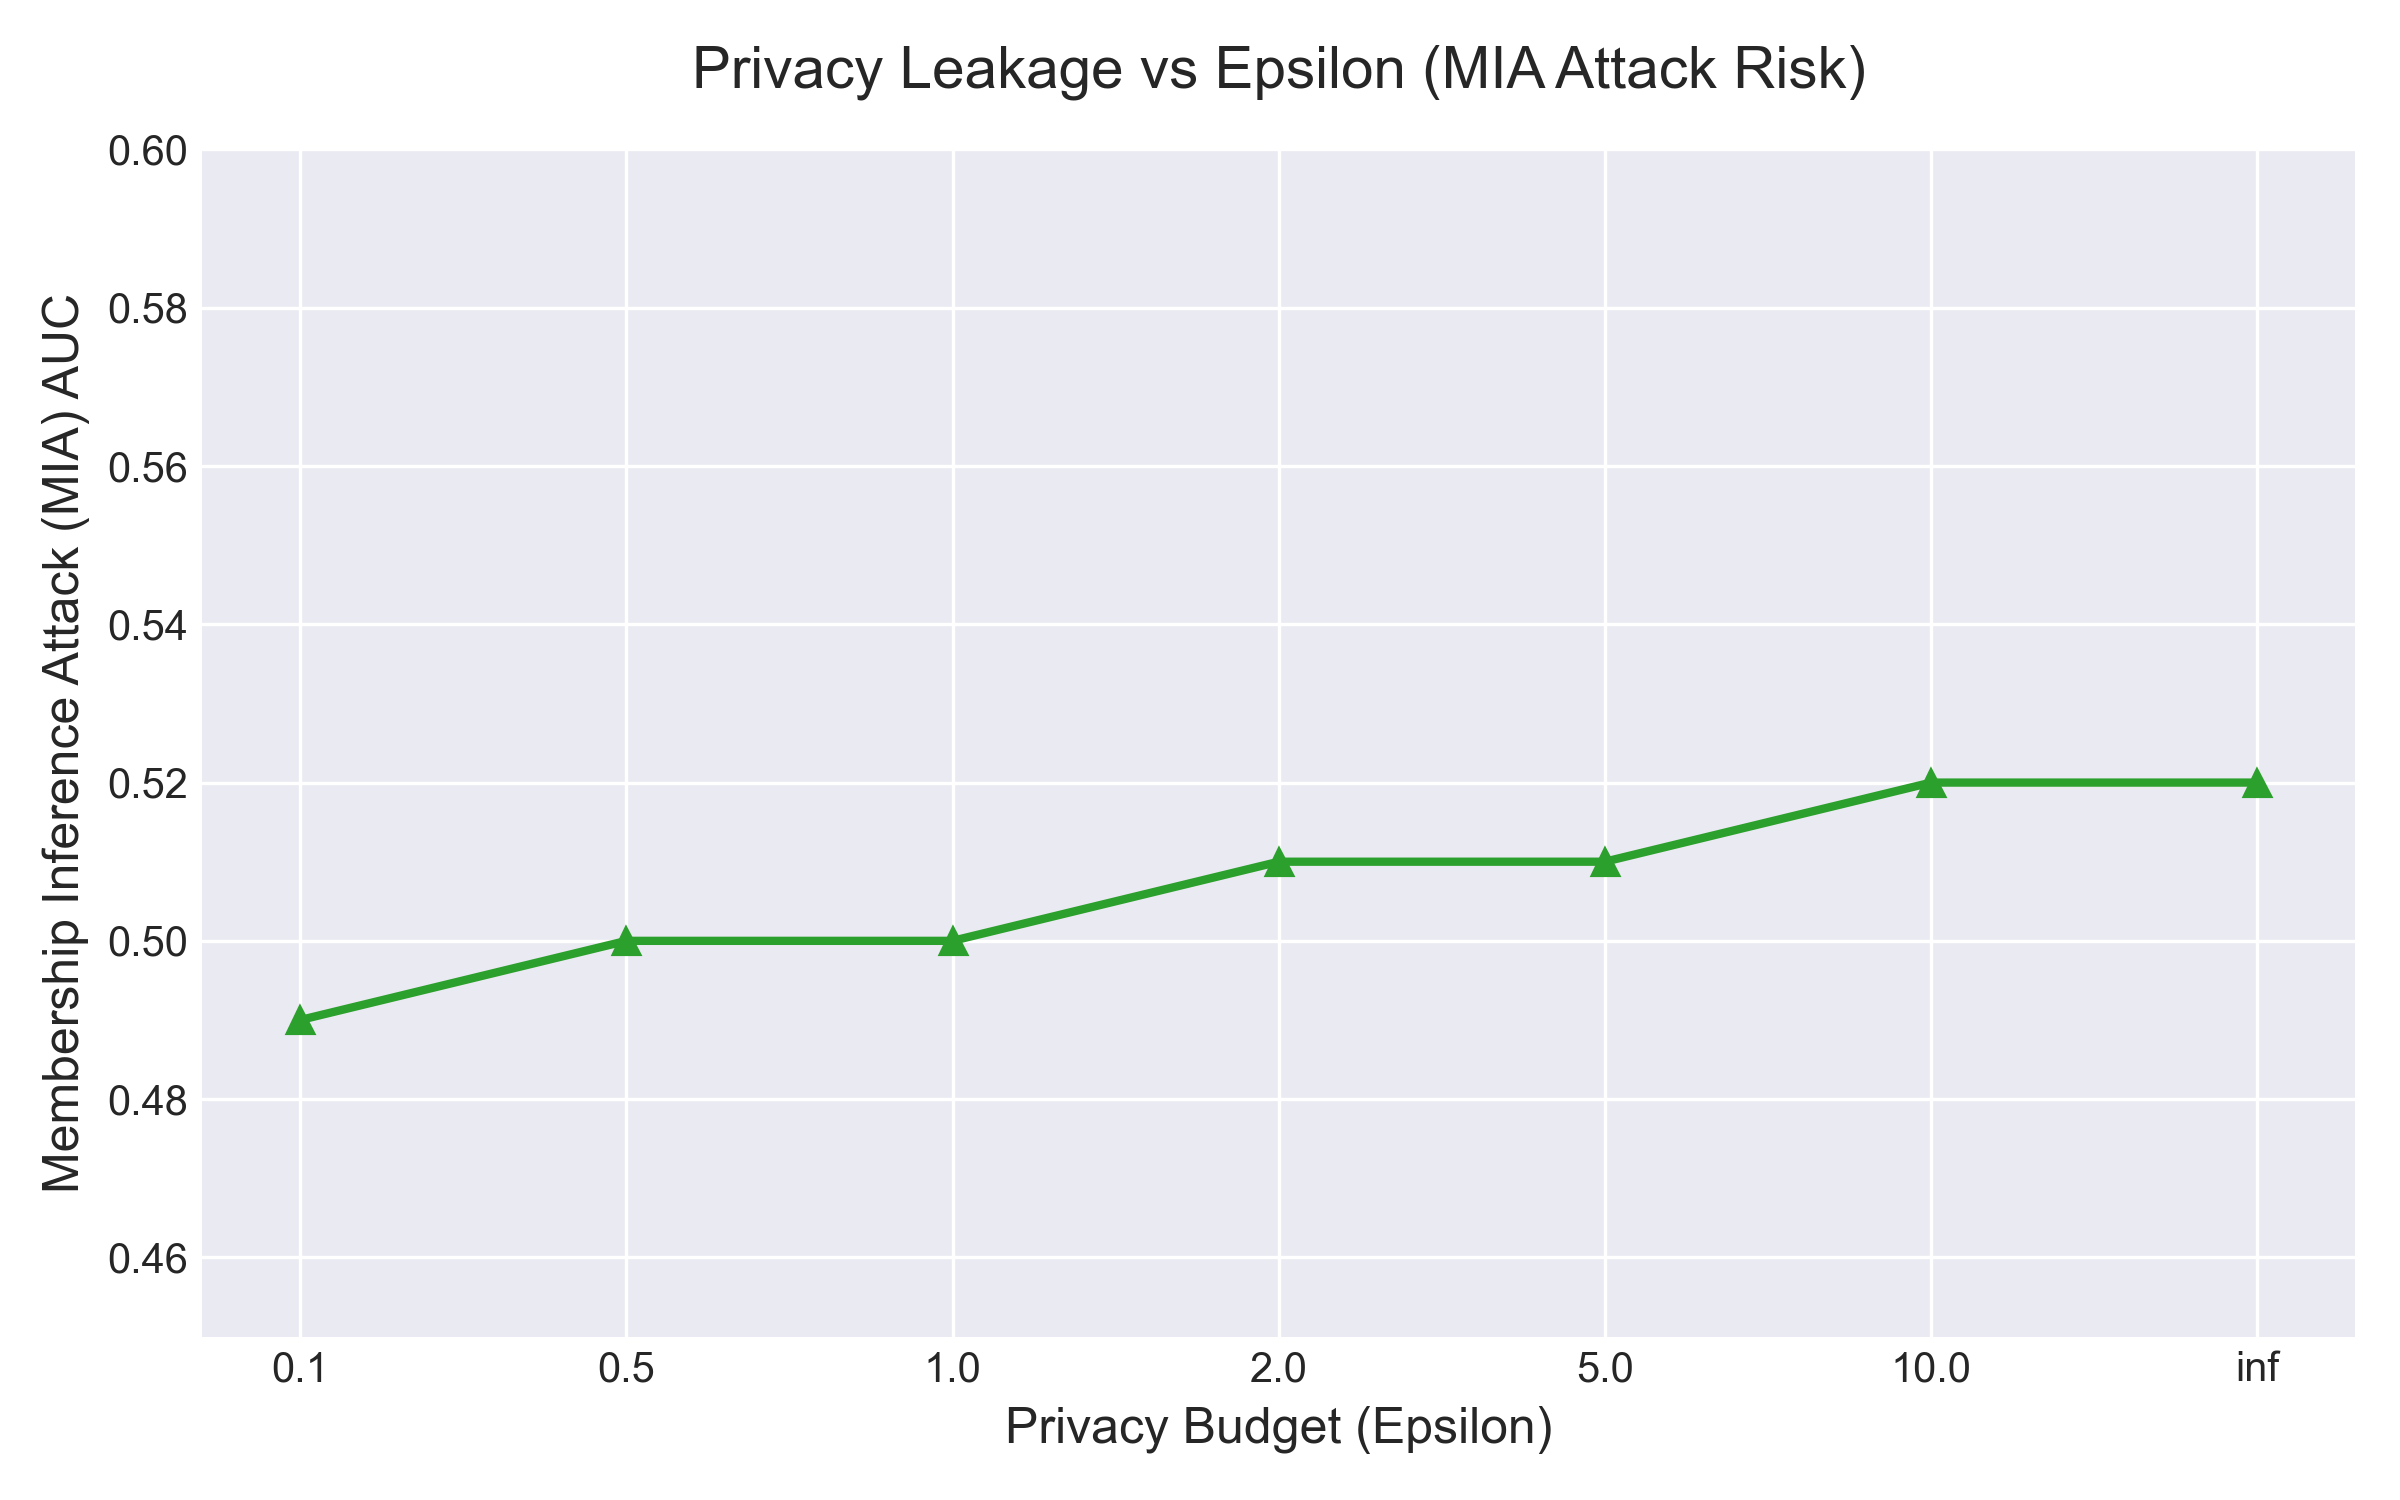

In [1]:
from pathlib import Path
import json
import sys
from IPython.display import Image, display

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    return cwd

PROJECT_ROOT = resolve_project_root()
REPORTS_DIR = PROJECT_ROOT / 'outputs' / 'reports'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'

# 1. Run or Load Ablation Study
ablation_path = REPORTS_DIR / 'ablation_explainability.json'
if not ablation_path.exists():
    print('Running ablation script...')
    sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
    import run_ablation
    run_ablation.main()

ablation_res = json.loads(ablation_path.read_text(encoding='utf-8'))
print('Best Config:', ablation_res['best_tradeoff_config'])
print('Ablation Study Completed successfully!')

tradeoff_img = FIGURES_DIR / 'privacy_utility_tradeoff.png'
if tradeoff_img.exists():
    display(Image(filename=str(tradeoff_img)))

mia_img = FIGURES_DIR / 'mia_vs_epsilon.png'
if mia_img.exists():
    display(Image(filename=str(mia_img)))

## 2. Integrated Gradients Feature Attribution
Berikut adalah analisis kontribusi karakter/tombol dalam password `.tie5Roanl` terhadap klasifikasi model.

Summary of attributions: {'most_important_character': 't', 'most_important_feature': 'Flight time (DD)', 'note': 'Attributions successfully generated using PyTorch Integrated Gradients.'}


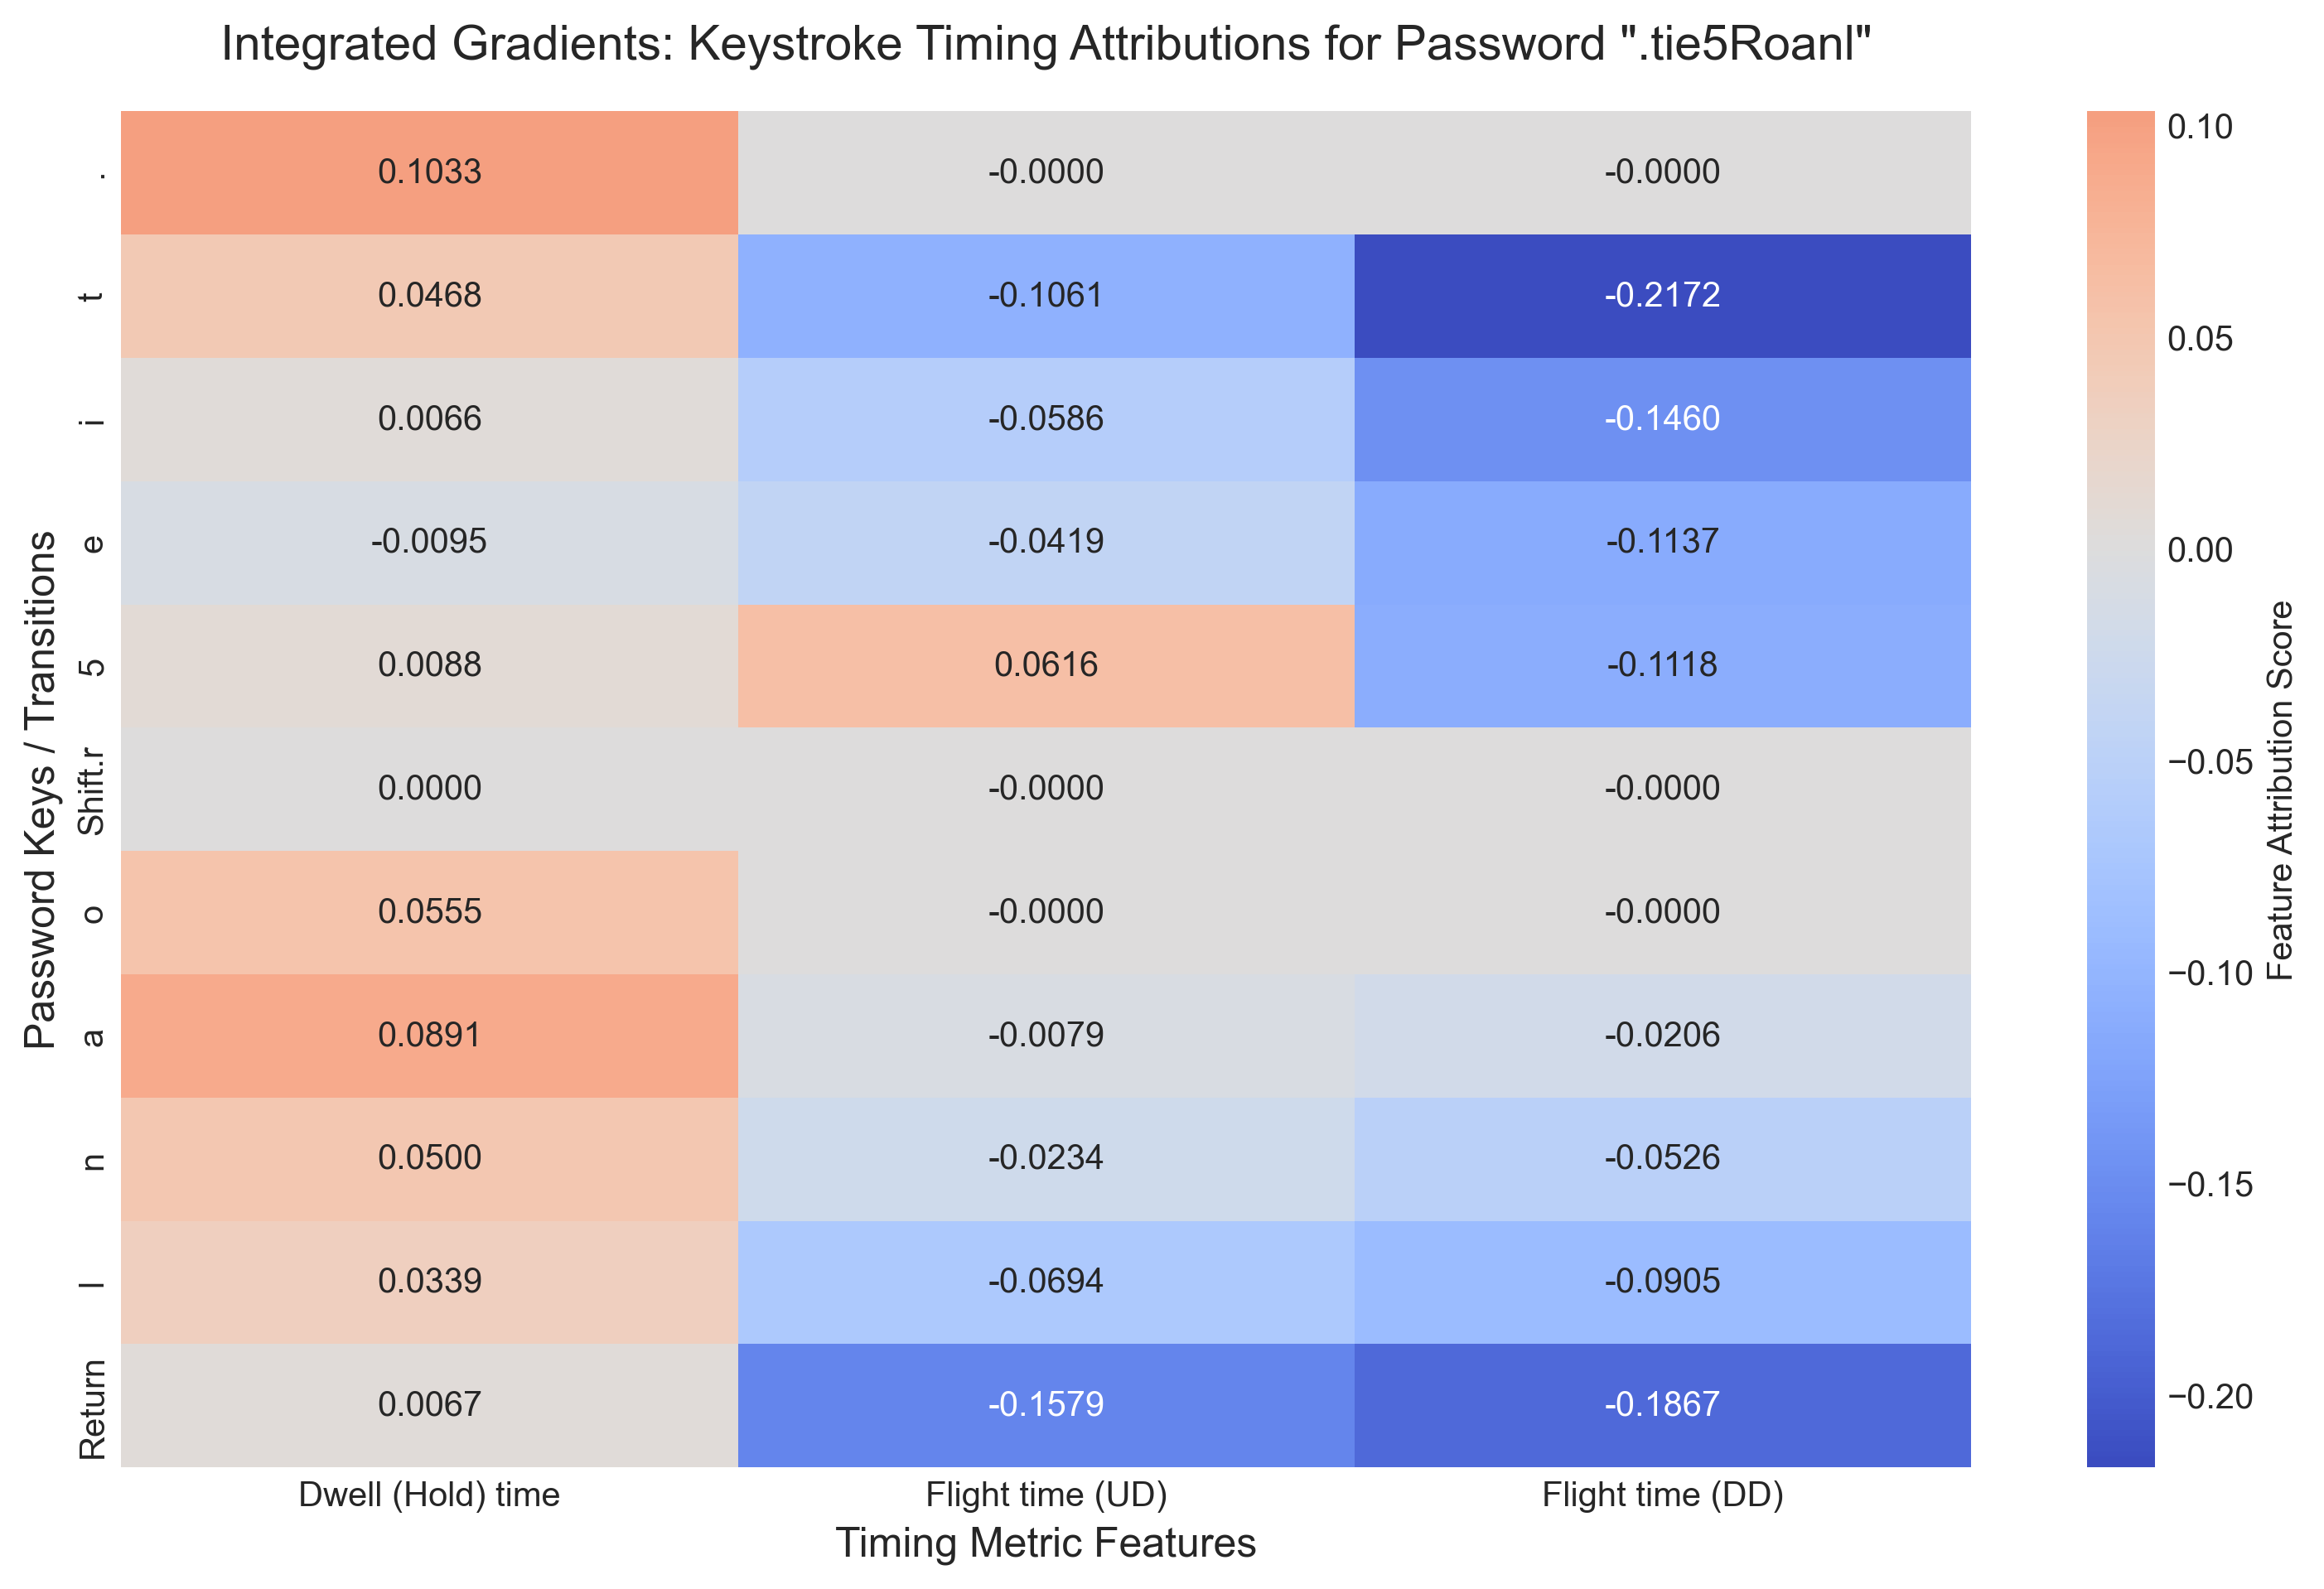

In [2]:
# 2. Run or Load Explainability attributions
explain_path = REPORTS_DIR / 'explainability_summary.json'
if not explain_path.exists():
    print('Running explainability script...')
    import run_explainability
    run_explainability.main()

explain_res = json.loads(explain_path.read_text(encoding='utf-8'))
print('Summary of attributions:', explain_res['summary'])

explain_img = FIGURES_DIR / 'keystroke_feature_importance.png'
if explain_img.exists():
    display(Image(filename=str(explain_img)))